# 🔄 Recurrent Neural Network (RNN) Tutorial

## Learning Objectives

By the end of this tutorial, you will:
- Understand what RNNs are and how they differ from regular neural networks
- Learn how RNNs process sequential data
- Understand hidden states and time steps
- Build RNNs with different configurations (SimpleRNN, LSTM, GRU)
- Visualize RNN architecture and data flow
- Apply RNNs to time series prediction problems
- Compare RNN performance with feedforward networks

---

## What is a Recurrent Neural Network (RNN)?

A **Recurrent Neural Network (RNN)** is a type of neural network designed to process **sequences of data** by maintaining a "memory" of previous inputs.

### Key Difference from Regular Neural Networks:

| Feature | Regular NN | RNN |
|---------|-----------|-----|
| **Input** | Single data point | Sequence of data points |
| **Memory** | No memory | Maintains hidden state |
| **Processing** | All at once | One timestep at a time |
| **Use Case** | Static data | Time series, sequences |

### Why RNNs?

- **Sequential Data**: Natural for time series, text, speech
- **Temporal Patterns**: Can learn patterns that depend on order
- **Memory**: Remembers information from previous timesteps
- **Context**: Uses context from past to predict future

### Common Applications:

- Time series forecasting (stock prices, weather)
- Natural language processing (text generation, translation)
- Speech recognition
- RUL prediction (engine degradation over time)

---

## Step 1: Import Required Libraries

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch, FancyBboxPatch
from matplotlib.patches import Arrow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras for RNNs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set visualization style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

2026-02-13 20:41:28.079601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Libraries imported successfully!
TensorFlow version: 2.20.0


## Step 2: Understanding RNN Architecture - Visualizations

Let's visualize how RNNs work compared to regular neural networks!

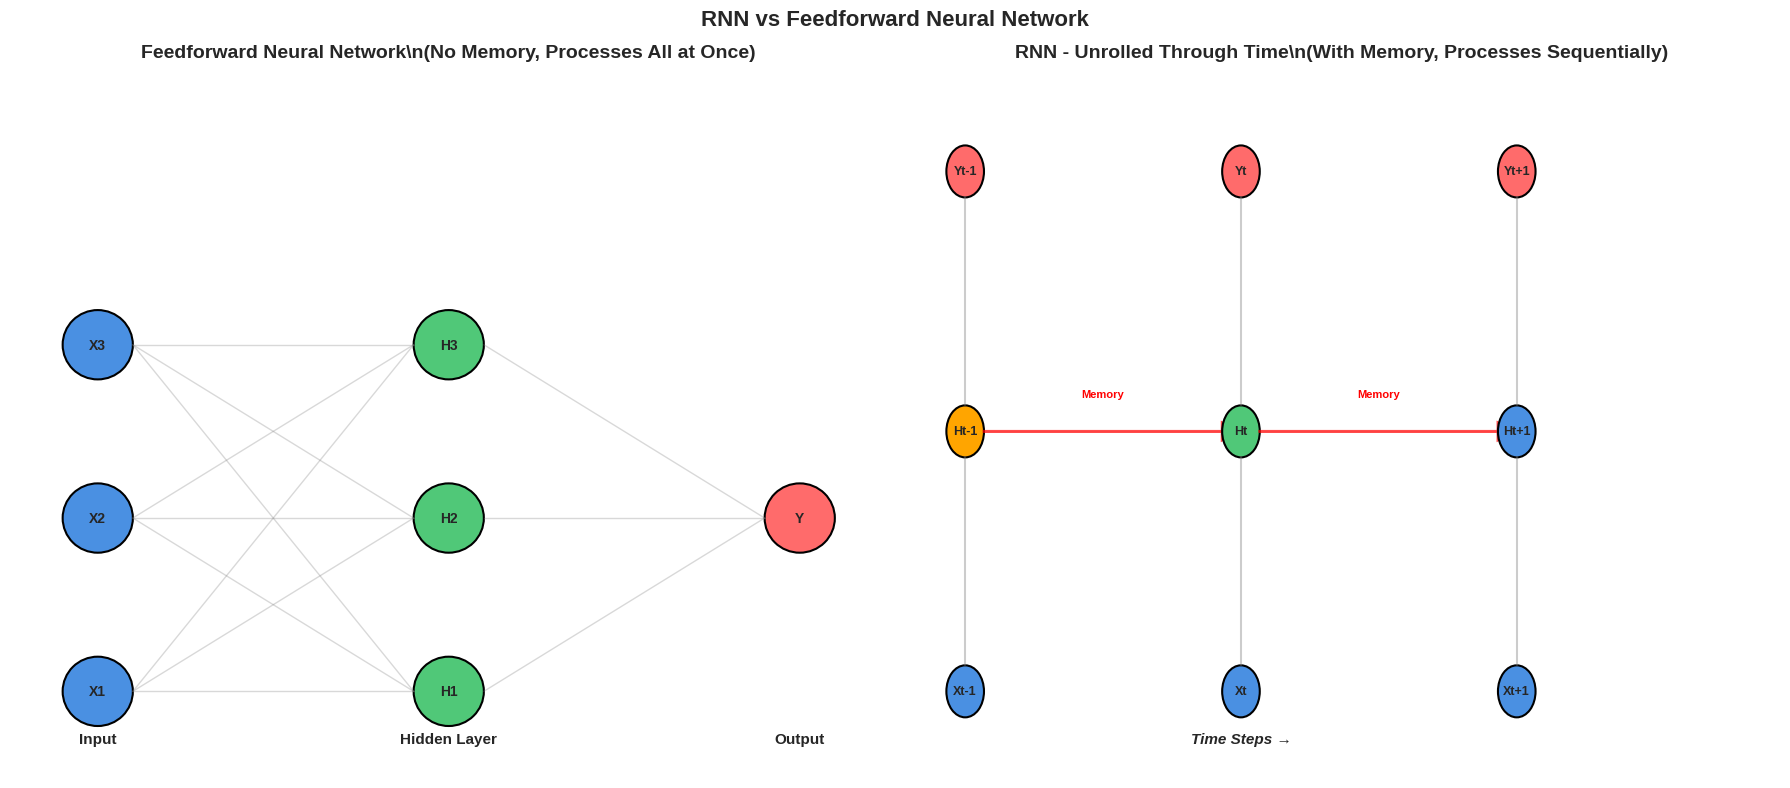

✅ RNN architecture visualization created!
\n💡 Key Observations:
   - Feedforward: All inputs processed simultaneously, no memory
   - RNN: Processes one timestep at a time, maintains hidden state (memory)
   - RNN's recurrent connection allows information to flow through time


In [2]:
# Visualize RNN vs Feedforward Network
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('RNN vs Feedforward Neural Network', fontsize=16, fontweight='bold')

# Feedforward Network
ax1 = axes[0]
ax1.set_xlim(-0.5, 4.5)
ax1.set_ylim(-0.5, 3.5)
ax1.axis('off')
ax1.set_title('Feedforward Neural Network\\n(No Memory, Processes All at Once)', 
              fontsize=14, fontweight='bold', pad=20)

# Input layer
for i in range(3):
    circle = Circle((0, i), 0.2, color='#4A90E2', ec='black', lw=1.5)
    ax1.add_patch(circle)
    ax1.text(0, i, f'X{i+1}', ha='center', va='center', fontsize=10, fontweight='bold')

# Hidden layer
for i in range(3):
    circle = Circle((2, i), 0.2, color='#50C878', ec='black', lw=1.5)
    ax1.add_patch(circle)
    ax1.text(2, i, f'H{i+1}', ha='center', va='center', fontsize=10, fontweight='bold')

# Output layer
circle = Circle((4, 1), 0.2, color='#FF6B6B', ec='black', lw=1.5)
ax1.add_patch(circle)
ax1.text(4, 1, 'Y', ha='center', va='center', fontsize=10, fontweight='bold')

# Connections
for i in range(3):
    for j in range(3):
        ax1.plot([0.2, 1.8], [i, j], 'gray', alpha=0.3, linewidth=1)
    ax1.plot([2.2, 3.8], [i, 1], 'gray', alpha=0.3, linewidth=1)

ax1.text(2, -0.3, 'Hidden Layer', ha='center', fontsize=11, fontweight='bold')
ax1.text(0, -0.3, 'Input', ha='center', fontsize=11, fontweight='bold')
ax1.text(4, -0.3, 'Output', ha='center', fontsize=11, fontweight='bold')

# RNN - Unrolled
ax2 = axes[1]
ax2.set_xlim(-0.5, 6.5)
ax2.set_ylim(-0.5, 3.5)
ax2.axis('off')
ax2.set_title('RNN - Unrolled Through Time\\n(With Memory, Processes Sequentially)', 
              fontsize=14, fontweight='bold', pad=20)

# Time steps
time_steps = ['t-1', 't', 't+1']
colors_hidden = ['#FFA500', '#50C878', '#4A90E2']  # Orange, Green, Blue

for t_idx, t_label in enumerate(time_steps):
    x_offset = t_idx * 2.2
    
    # Input
    circle = Circle((x_offset, 0), 0.15, color='#4A90E2', ec='black', lw=1.5)
    ax2.add_patch(circle)
    ax2.text(x_offset, 0, f'X{t_label}', ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Hidden state
    circle = Circle((x_offset, 1.5), 0.15, color=colors_hidden[t_idx], ec='black', lw=1.5)
    ax2.add_patch(circle)
    ax2.text(x_offset, 1.5, f'H{t_label}', ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Output
    circle = Circle((x_offset, 3), 0.15, color='#FF6B6B', ec='black', lw=1.5)
    ax2.add_patch(circle)
    ax2.text(x_offset, 3, f'Y{t_label}', ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Connections within timestep
    ax2.plot([x_offset, x_offset], [0.15, 1.35], 'gray', alpha=0.4, linewidth=1.5)
    ax2.plot([x_offset, x_offset], [1.65, 2.85], 'gray', alpha=0.4, linewidth=1.5)
    
    # Recurrent connection (hidden to next hidden)
    if t_idx < len(time_steps) - 1:
        ax2.arrow(x_offset + 0.15, 1.5, 1.9, 0, head_width=0.1, head_length=0.15, 
                 fc='red', ec='red', linewidth=2, alpha=0.7)
        ax2.text(x_offset + 1.1, 1.7, 'Memory', ha='center', fontsize=8, color='red', fontweight='bold')

ax2.text(2.2, -0.3, 'Time Steps →', ha='center', fontsize=11, fontweight='bold', style='italic')

plt.tight_layout()
plt.show()

print("✅ RNN architecture visualization created!")
print("\\n💡 Key Observations:")
print("   - Feedforward: All inputs processed simultaneously, no memory")
print("   - RNN: Processes one timestep at a time, maintains hidden state (memory)")
print("   - RNN's recurrent connection allows information to flow through time")

## Step 3: Understanding RNN Cell Structure

Let's visualize the internal structure of an RNN cell to understand how it processes information.

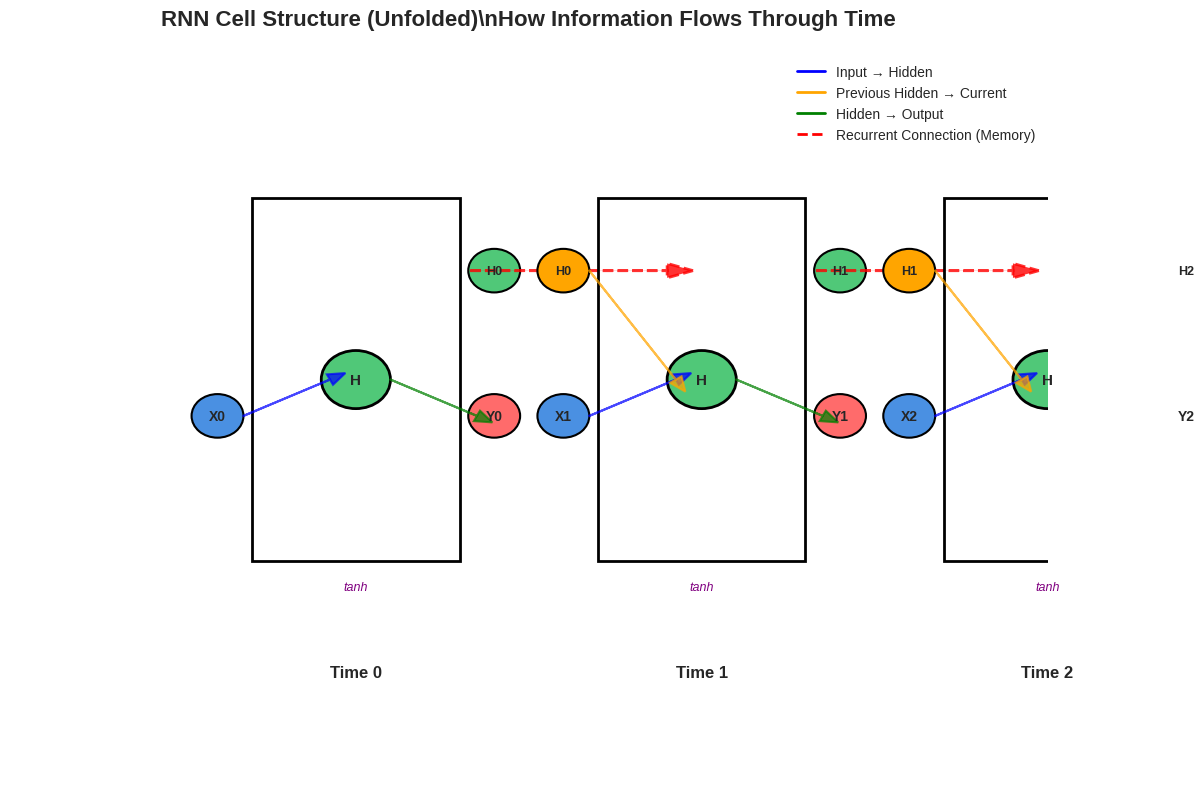

✅ RNN cell structure visualization created!
\n💡 Key Components:
   - Input (X): Current timestep data
   - Hidden State (H): Memory from previous timesteps
   - Output (Y): Prediction for current timestep
   - Recurrent Connection: Passes hidden state to next timestep
   - Activation: Usually tanh or ReLU


In [3]:
# Visualize RNN Cell Structure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 4)
ax.axis('off')
ax.set_title('RNN Cell Structure (Unfolded)\\nHow Information Flows Through Time', 
             fontsize=16, fontweight='bold', pad=20)

# Draw RNN cells at different time steps
time_steps = 3
cell_width = 1.5
cell_height = 2.5

for t in range(time_steps):
    x_center = t * 2 + 1
    
    # Draw cell box
    rect = Rectangle((x_center - 0.6, 0.5), 1.2, cell_height, 
                    fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    
    # Input
    circle_in = Circle((x_center - 0.8, 1.5), 0.15, color='#4A90E2', ec='black', lw=1.5)
    ax.add_patch(circle_in)
    ax.text(x_center - 0.8, 1.5, f'X{t}', ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Hidden state (previous)
    if t > 0:
        circle_h_prev = Circle((x_center - 0.8, 2.5), 0.15, color='#FFA500', ec='black', lw=1.5)
        ax.add_patch(circle_h_prev)
        ax.text(x_center - 0.8, 2.5, f'H{t-1}', ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Hidden state (current) - inside cell
    circle_h = Circle((x_center, 1.75), 0.2, color='#50C878', ec='black', lw=2)
    ax.add_patch(circle_h)
    ax.text(x_center, 1.75, 'H', ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Output
    circle_out = Circle((x_center + 0.8, 1.5), 0.15, color='#FF6B6B', ec='black', lw=1.5)
    ax.add_patch(circle_out)
    ax.text(x_center + 0.8, 1.5, f'Y{t}', ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Hidden state (next) - output
    circle_h_next = Circle((x_center + 0.8, 2.5), 0.15, color='#50C878', ec='black', lw=1.5)
    ax.add_patch(circle_h_next)
    ax.text(x_center + 0.8, 2.5, f'H{t}', ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Connections
    # Input to hidden
    ax.arrow(x_center - 0.65, 1.5, 0.5, 0.25, head_width=0.08, head_length=0.1, 
            fc='blue', ec='blue', linewidth=1.5, alpha=0.7)
    
    # Previous hidden to current hidden
    if t > 0:
        ax.arrow(x_center - 0.65, 2.5, 0.5, -0.75, head_width=0.08, head_length=0.1, 
                fc='orange', ec='orange', linewidth=1.5, alpha=0.7)
    
    # Hidden to output
    ax.arrow(x_center + 0.2, 1.75, 0.5, -0.25, head_width=0.08, head_length=0.1, 
            fc='green', ec='green', linewidth=1.5, alpha=0.7)
    
    # Hidden to next hidden (recurrent)
    if t < time_steps - 1:
        ax.arrow(x_center + 0.65, 2.5, 1.15, 0, head_width=0.1, head_length=0.15, 
                fc='red', ec='red', linewidth=2, alpha=0.8, linestyle='--')
    
    # Time label
    ax.text(x_center, -0.3, f'Time {t}', ha='center', fontsize=12, fontweight='bold')
    
    # Activation function label
    ax.text(x_center, 0.3, 'tanh', ha='center', fontsize=9, style='italic', color='purple')

# Add legend
legend_elements = [
    plt.Line2D([0], [0], color='blue', lw=2, label='Input → Hidden'),
    plt.Line2D([0], [0], color='orange', lw=2, label='Previous Hidden → Current'),
    plt.Line2D([0], [0], color='green', lw=2, label='Hidden → Output'),
    plt.Line2D([0], [0], color='red', lw=2, linestyle='--', label='Recurrent Connection (Memory)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ RNN cell structure visualization created!")
print("\\n💡 Key Components:")
print("   - Input (X): Current timestep data")
print("   - Hidden State (H): Memory from previous timesteps")
print("   - Output (Y): Prediction for current timestep")
print("   - Recurrent Connection: Passes hidden state to next timestep")
print("   - Activation: Usually tanh or ReLU")

✅ Time series dataset created!
   - Samples: 1000
   - Features: 3
   - Target range: [-1.99, 6.16]


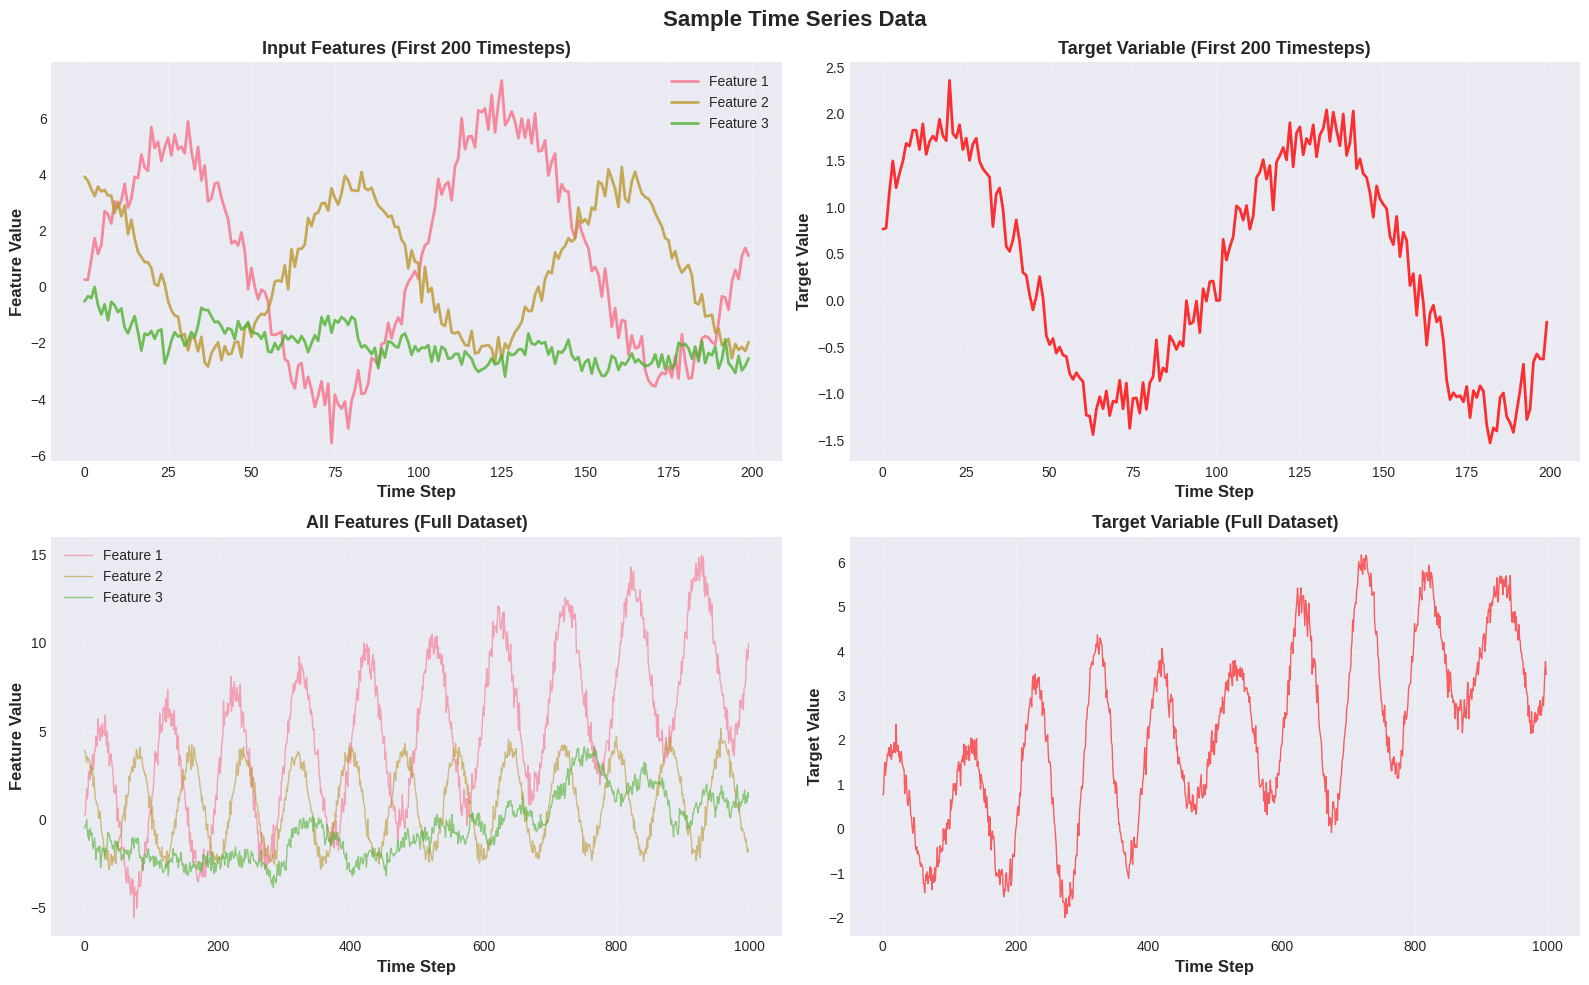

✅ Time series visualization created!


In [4]:
# Create a synthetic time series dataset
np.random.seed(42)
n_samples = 1000
n_features = 3

# Generate time series with trends, seasonality, and noise
time = np.arange(n_samples)
X = np.zeros((n_samples, n_features))

# Feature 1: Linear trend + sine wave + noise
X[:, 0] = 0.01 * time + 5 * np.sin(2 * np.pi * time / 100) + np.random.normal(0, 0.5, n_samples)

# Feature 2: Exponential trend + cosine wave + noise
X[:, 1] = 0.5 * np.exp(0.001 * time) + 3 * np.cos(2 * np.pi * time / 80) + np.random.normal(0, 0.3, n_samples)

# Feature 3: Random walk + noise
X[:, 2] = np.cumsum(np.random.normal(0, 0.2, n_samples)) + np.random.normal(0, 0.2, n_samples)

# Create target: combination of features with lag (depends on past values)
y = (0.3 * X[:, 0] + 
     0.2 * X[:, 1] + 
     0.1 * X[:, 2] + 
     0.1 * np.roll(X[:, 0], 1) +  # Previous timestep
     0.05 * np.roll(X[:, 1], 2) +  # Two timesteps ago
     np.random.normal(0, 0.1, n_samples))

# Remove NaN from roll operations
y[0] = 0.3 * X[0, 0] + 0.2 * X[0, 1] + 0.1 * X[0, 2] + np.random.normal(0, 0.1)
y[1] = 0.3 * X[1, 0] + 0.2 * X[1, 1] + 0.1 * X[1, 2] + 0.1 * X[0, 0] + np.random.normal(0, 0.1)

print("✅ Time series dataset created!")
print(f"   - Samples: {n_samples}")
print(f"   - Features: {n_features}")
print(f"   - Target range: [{y.min():.2f}, {y.max():.2f}]")

# Visualize the time series
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Sample Time Series Data', fontsize=16, fontweight='bold')

# Plot features
for i in range(n_features):
    axes[0, 0].plot(time[:200], X[:200, i], label=f'Feature {i+1}', linewidth=2, alpha=0.8)
axes[0, 0].set_xlabel('Time Step', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Feature Value', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Input Features (First 200 Timesteps)', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot target
axes[0, 1].plot(time[:200], y[:200], color='red', linewidth=2, alpha=0.8)
axes[0, 1].set_xlabel('Time Step', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Target Value', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Target Variable (First 200 Timesteps)', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Full time series
axes[1, 0].plot(time, X[:, 0], label='Feature 1', alpha=0.6, linewidth=1)
axes[1, 0].plot(time, X[:, 1], label='Feature 2', alpha=0.6, linewidth=1)
axes[1, 0].plot(time, X[:, 2], label='Feature 3', alpha=0.6, linewidth=1)
axes[1, 0].set_xlabel('Time Step', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Feature Value', fontsize=12, fontweight='bold')
axes[1, 0].set_title('All Features (Full Dataset)', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(time, y, color='red', alpha=0.6, linewidth=1)
axes[1, 1].set_xlabel('Time Step', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Target Value', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Target Variable (Full Dataset)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Time series visualization created!")

## Step 5: Prepare Sequences for RNN

RNNs need sequences, not individual data points. We'll create sequences of past timesteps to predict the next value.

✅ Sequences created!
   - Original data shape: (1000, 3)
   - Sequence data shape: (981, 20, 3)
   -   → 981 sequences
   -   → Each sequence has 20 timesteps
   -   → Each timestep has 3 features
   - Target shape: (981,)


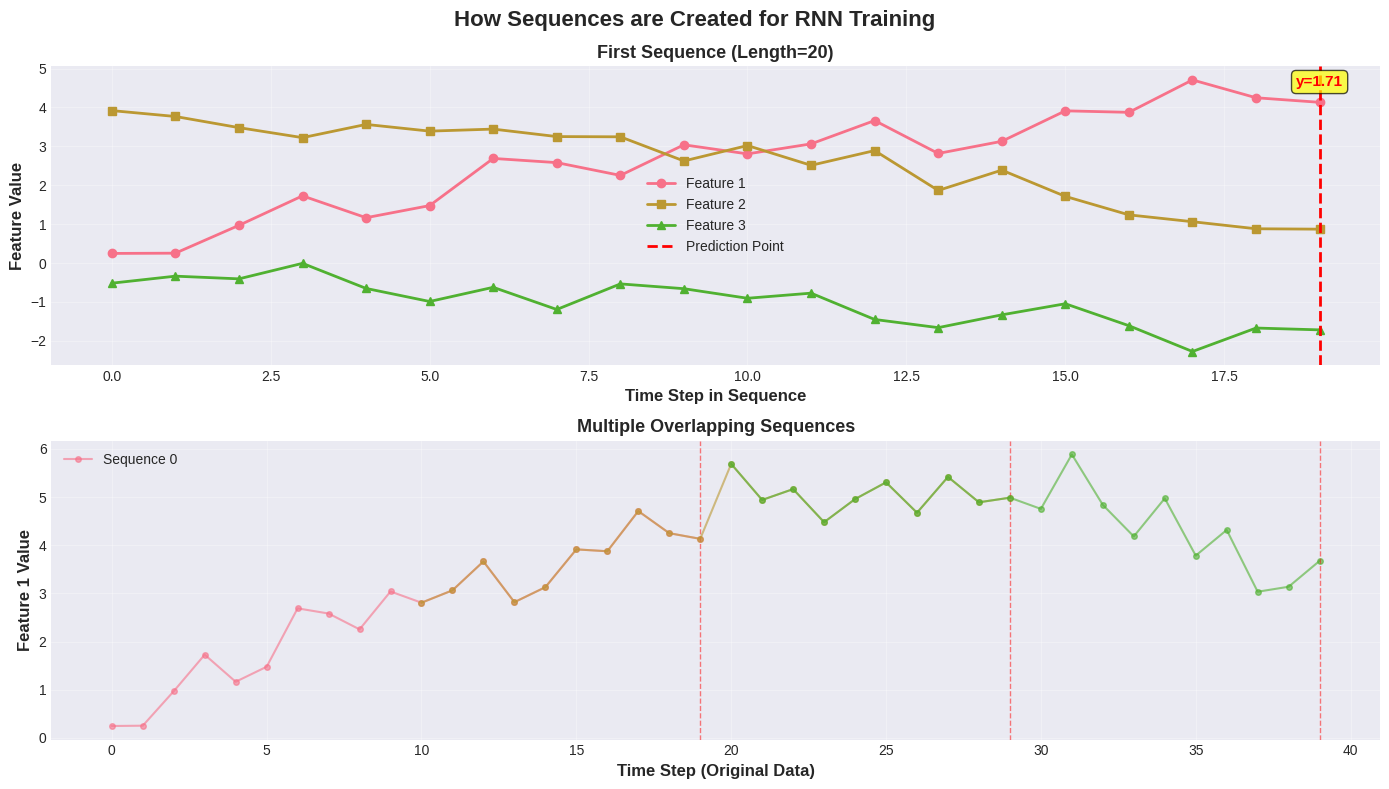

\n💡 Understanding Sequences:
   - Each sequence contains 20 consecutive timesteps
   - Sequences overlap (sliding window)
   - Target is the value at the END of each sequence
   - RNN uses all timesteps in sequence to make prediction


In [5]:
def create_sequences(X, y, sequence_length=10):
    """
    Create sequences for RNN training
    
    Parameters:
    -----------
    X : array, shape (n_samples, n_features)
        Input features
    y : array, shape (n_samples,)
        Target values
    sequence_length : int
        Number of timesteps to use for prediction
    
    Returns:
    --------
    X_seq : array, shape (n_sequences, sequence_length, n_features)
        Input sequences
    y_seq : array, shape (n_sequences,)
        Target values for each sequence
    """
    X_seq = []
    y_seq = []
    
    for i in range(len(X) - sequence_length + 1):
        X_seq.append(X[i:i+sequence_length])
        y_seq.append(y[i+sequence_length-1])  # Predict value at end of sequence
    
    return np.array(X_seq), np.array(y_seq)

# Create sequences
sequence_length = 20  # Use 20 timesteps to predict next value
X_seq, y_seq = create_sequences(X, y, sequence_length)

print("✅ Sequences created!")
print(f"   - Original data shape: {X.shape}")
print(f"   - Sequence data shape: {X_seq.shape}")
print(f"   -   → {X_seq.shape[0]} sequences")
print(f"   -   → Each sequence has {X_seq.shape[1]} timesteps")
print(f"   -   → Each timestep has {X_seq.shape[2]} features")
print(f"   - Target shape: {y_seq.shape}")

# Visualize how sequences are created
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('How Sequences are Created for RNN Training', fontsize=16, fontweight='bold')

# Show first sequence
axes[0].plot(range(sequence_length), X_seq[0, :, 0], 'o-', label='Feature 1', linewidth=2, markersize=6)
axes[0].plot(range(sequence_length), X_seq[0, :, 1], 's-', label='Feature 2', linewidth=2, markersize=6)
axes[0].plot(range(sequence_length), X_seq[0, :, 2], '^-', label='Feature 3', linewidth=2, markersize=6)
axes[0].axvline(x=sequence_length-1, color='red', linestyle='--', linewidth=2, label='Prediction Point')
axes[0].set_xlabel('Time Step in Sequence', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Feature Value', fontsize=12, fontweight='bold')
axes[0].set_title(f'First Sequence (Length={sequence_length})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(sequence_length-1, axes[0].get_ylim()[1]*0.9, f'y={y_seq[0]:.2f}', 
            ha='center', fontsize=11, fontweight='bold', color='red',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Show multiple sequences
for seq_idx in [0, 10, 20]:
    axes[1].plot(range(seq_idx, seq_idx + sequence_length), 
                X_seq[seq_idx, :, 0], 'o-', alpha=0.6, linewidth=1.5, markersize=4,
                label=f'Sequence {seq_idx}' if seq_idx < 3 else '')
    axes[1].axvline(x=seq_idx + sequence_length - 1, color='red', linestyle='--', 
                    linewidth=1, alpha=0.5)

axes[1].set_xlabel('Time Step (Original Data)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Feature 1 Value', fontsize=12, fontweight='bold')
axes[1].set_title('Multiple Overlapping Sequences', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\\n💡 Understanding Sequences:")
print(f"   - Each sequence contains {sequence_length} consecutive timesteps")
print("   - Sequences overlap (sliding window)")
print("   - Target is the value at the END of each sequence")
print("   - RNN uses all timesteps in sequence to make prediction")

## Step 6: Split and Scale Data

In [6]:
# Split into training and testing sets
# Important: For time series, we should use chronological split
split_idx = int(0.8 * len(X_seq))
X_train_seq = X_seq[:split_idx]
X_test_seq = X_seq[split_idx:]
y_train_seq = y_seq[:split_idx]
y_test_seq = y_seq[split_idx:]

# Scale the features (important for RNNs!)
# Reshape for scaling: (samples * timesteps, features)
n_samples_train, n_timesteps, n_features = X_train_seq.shape
X_train_reshaped = X_train_seq.reshape(-1, n_features)
X_test_reshaped = X_test_seq.reshape(-1, n_features)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

# Reshape back to sequences
X_train_seq_scaled = X_train_scaled.reshape(n_samples_train, n_timesteps, n_features)
X_test_seq_scaled = X_test_scaled.reshape(X_test_seq.shape[0], n_timesteps, n_features)

print("✅ Data prepared!")
print(f"   - Training sequences: {X_train_seq_scaled.shape[0]:,}")
print(f"   - Test sequences: {X_test_seq_scaled.shape[0]:,}")
print(f"   - Sequence length: {n_timesteps}")
print(f"   - Features per timestep: {n_features}")
print(f"   - Data shape: (samples, timesteps, features) = {X_train_seq_scaled.shape}")

✅ Data prepared!
   - Training sequences: 784
   - Test sequences: 197
   - Sequence length: 20
   - Features per timestep: 3
   - Data shape: (samples, timesteps, features) = (784, 20, 3)


## Step 7: Build and Train Simple RNN

Let's start with a basic SimpleRNN to understand the fundamentals.

In [7]:
# Build Simple RNN model
model_simple_rnn = Sequential([
    SimpleRNN(64, activation='tanh', return_sequences=False, 
              input_shape=(n_timesteps, n_features), name='rnn_layer_1'),
    Dense(32, activation='relu', name='dense_layer_1'),
    Dense(1, name='output_layer')
])

# Compile the model
model_simple_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Display model architecture
print("📊 Simple RNN Architecture:")
print("=" * 60)
model_simple_rnn.summary()

print("\\n💡 Architecture Explanation:")
print("   - SimpleRNN(64): 64 hidden units, processes sequences")
print("   - return_sequences=False: Only output at last timestep")
print("   - Dense layers: Process RNN output to make final prediction")

📊 Simple RNN Architecture:


2026-02-13 20:41:32.987416: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_layer_1 (SimpleRNN)         │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_1 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465 (25.25 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

\n💡 Architecture Explanation:
   - SimpleRNN(64): 64 hidden units, processes sequences
   - return_sequences=False: Only output at last timestep
   - Dense layers: Process RNN output to make final prediction


In [8]:
# Train the Simple RNN model
print("🚀 Training Simple RNN...")
print("=" * 60)

history_simple_rnn = model_simple_rnn.fit(
    X_train_seq_scaled, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

print("\\n✅ Training completed!")

🚀 Training Simple RNN...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.2387 - mae: 1.1295 - val_loss: 3.9823 - val_mae: 1.6494
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2615 - mae: 0.3979 - val_loss: 1.7143 - val_mae: 1.0340
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1353 - mae: 0.2884 - val_loss: 1.2957 - val_mae: 0.9152
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0840 - mae: 0.2284 - val_loss: 0.9514 - val_mae: 0.7973
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0648 - mae: 0.2027 - val_loss: 0.8680 - val_mae: 0.7656
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0516 - mae: 0.1816 - val_loss: 0.8590 - val_mae: 0.7577
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0414 - mae: 0.1637 - val_loss: 0.7664 - val_mae: 0.7204
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0360 - mae: 0.1521 - val_loss: 0.7180 - val_mae: 0.7023
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/s

In [9]:
# Evaluate Simple RNN
y_pred_simple_rnn = model_simple_rnn.predict(X_test_seq_scaled, verbose=0)

mse_simple_rnn = mean_squared_error(y_test_seq, y_pred_simple_rnn)
mae_simple_rnn = mean_absolute_error(y_test_seq, y_pred_simple_rnn)
rmse_simple_rnn = np.sqrt(mse_simple_rnn)
r2_simple_rnn = r2_score(y_test_seq, y_pred_simple_rnn)

print("📊 Simple RNN Performance:")
print("=" * 60)
print(f"MSE:  {mse_simple_rnn:.4f}")
print(f"MAE:  {mae_simple_rnn:.4f}")
print(f"RMSE: {rmse_simple_rnn:.4f}")
print(f"R²:   {r2_simple_rnn:.4f}")

📊 Simple RNN Performance:
MSE:  0.3019
MAE:  0.4459
RMSE: 0.5494
R²:   0.7617


## Step 8: Build and Train LSTM (Long Short-Term Memory)

LSTM is an improved RNN that can remember information for longer periods.

In [10]:
# Build LSTM model
model_lstm = Sequential([
    LSTM(64, activation='tanh', return_sequences=False, 
         input_shape=(n_timesteps, n_features), name='lstm_layer_1'),
    Dense(32, activation='relu', name='dense_layer_1'),
    Dense(1, name='output_layer')
])

# Compile the model
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Display model architecture
print("📊 LSTM Architecture:")
print("=" * 60)
model_lstm.summary()

print("\\n💡 LSTM Advantages:")
print("   - Can remember information for longer periods")
print("   - Better at learning long-term dependencies")
print("   - More stable training (less vanishing gradient problem)")
print("   - Uses gates (forget, input, output) to control information flow")

📊 LSTM Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_1 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,521 (76.25 KB)

 Non-trainable params: 0 (0.00 B)

\n💡 LSTM Advantages:
   - Can remember information for longer periods
   - Better at learning long-term dependencies
   - More stable training (less vanishing gradient problem)
   - Uses gates (forget, input, output) to control information flow


In [11]:
# Train the LSTM model
print("🚀 Training LSTM...")
print("=" * 60)

history_lstm = model_lstm.fit(
    X_train_seq_scaled, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

print("\\n✅ Training completed!")

🚀 Training LSTM...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.4323 - mae: 1.4911 - val_loss: 5.9895 - val_mae: 2.0284
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8120 - mae: 0.7523 - val_loss: 1.7502 - val_mae: 1.1012
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3293 - mae: 0.4843 - val_loss: 1.0796 - val_mae: 0.8734
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1739 - mae: 0.3337 - val_loss: 0.7741 - val_mae: 0.7306
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0968 - mae: 0.2455 - val_loss: 0.6444 - val_mae: 0.6657
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0681 - mae: 0.2089 - val_loss: 0.5803 - val_mae: 0.6295
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0551 - mae: 0.1909 - val_loss: 0.5486 - val_mae: 0.6062
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0478 - mae: 0.1795 - val_loss: 0.5198 - val_mae: 0.5865
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - 

In [12]:
# Evaluate LSTM
y_pred_lstm = model_lstm.predict(X_test_seq_scaled, verbose=0)

mse_lstm = mean_squared_error(y_test_seq, y_pred_lstm)
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

print("📊 LSTM Performance:")
print("=" * 60)
print(f"MSE:  {mse_lstm:.4f}")
print(f"MAE:  {mae_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")
print(f"R²:   {r2_lstm:.4f}")

📊 LSTM Performance:
MSE:  0.2387
MAE:  0.4217
RMSE: 0.4886
R²:   0.8115


torial 

In [13]:
# Build GRU model
model_gru = Sequential([
    GRU(64, activation='tanh', return_sequences=False, 
        input_shape=(n_timesteps, n_features), name='gru_layer_1'),
    Dense(32, activation='relu', name='dense_layer_1'),
    Dense(1, name='output_layer')
])

# Compile the model
model_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Display model architecture
print("📊 GRU Architecture:")
print("=" * 60)
model_gru.summary()

print("\\n💡 GRU Characteristics:")
print("   - Simpler than LSTM (fewer parameters)")
print("   - Uses reset and update gates")
print("   - Often performs similarly to LSTM")
print("   - Faster to train than LSTM")

📊 GRU Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_layer_1 (GRU)               │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_1 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 15,361 (60.00 KB)

 Non-trainable params: 0 (0.00 B)

\n💡 GRU Characteristics:
   - Simpler than LSTM (fewer parameters)
   - Uses reset and update gates
   - Often performs similarly to LSTM
   - Faster to train than LSTM


In [14]:
# Train the GRU model
print("🚀 Training GRU...")
print("=" * 60)

history_gru = model_gru.fit(
    X_train_seq_scaled, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

print("\\n✅ Training completed!")

🚀 Training GRU...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.1409 - mae: 1.4295 - val_loss: 5.9548 - val_mae: 2.1743
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4791 - mae: 0.5388 - val_loss: 0.9408 - val_mae: 0.8504
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1514 - mae: 0.3142 - val_loss: 0.5086 - val_mae: 0.6062
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1101 - mae: 0.2653 - val_loss: 0.3624 - val_mae: 0.4922
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0788 - mae: 0.2228 - val_loss: 0.2612 - val_mae: 0.4165
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0659 - mae: 0.2036 - val_loss: 0.1928 - val_mae: 0.3582
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0546 - mae: 0.1854 - val_loss: 0.1457 - val_mae: 0.3151
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0454 - mae: 0.1692 - val_loss: 0.1110 - val_mae: 0.2779
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

In [15]:
# Evaluate GRU
y_pred_gru = model_gru.predict(X_test_seq_scaled, verbose=0)

mse_gru = mean_squared_error(y_test_seq, y_pred_gru)
mae_gru = mean_absolute_error(y_test_seq, y_pred_gru)
rmse_gru = np.sqrt(mse_gru)
r2_gru = r2_score(y_test_seq, y_pred_gru)

print("📊 GRU Performance:")
print("=" * 60)
print(f"MSE:  {mse_gru:.4f}")
print(f"MAE:  {mae_gru:.4f}")
print(f"RMSE: {rmse_gru:.4f}")
print(f"R²:   {r2_gru:.4f}")

📊 GRU Performance:
MSE:  0.0202
MAE:  0.1136
RMSE: 0.1421
R²:   0.9841


In [16]:
# Create comparison table
comparison_data = {
    'Model': ['SimpleRNN', 'LSTM', 'GRU'],
    'MSE': [mse_simple_rnn, mse_lstm, mse_gru],
    'MAE': [mae_simple_rnn, mae_lstm, mae_gru],
    'RMSE': [rmse_simple_rnn, rmse_lstm, rmse_gru],
    'R²': [r2_simple_rnn, r2_lstm, r2_gru]
}

comparison_df = pd.DataFrame(comparison_data)

print("📊 RNN Model Comparison:")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Find best model
best_model_idx = comparison_df['R²'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
print(f"\\n🏆 Best Model: {best_model} (R² = {comparison_df.loc[best_model_idx, 'R²']:.4f})")

📊 RNN Model Comparison:
    Model      MSE      MAE     RMSE       R²
SimpleRNN 0.301892 0.445852 0.549447 0.761663
     LSTM 0.238705 0.421732 0.488575 0.811547
      GRU 0.020190 0.113568 0.142091 0.984061
\n🏆 Best Model: GRU (R² = 0.9841)


with RUL prediction 

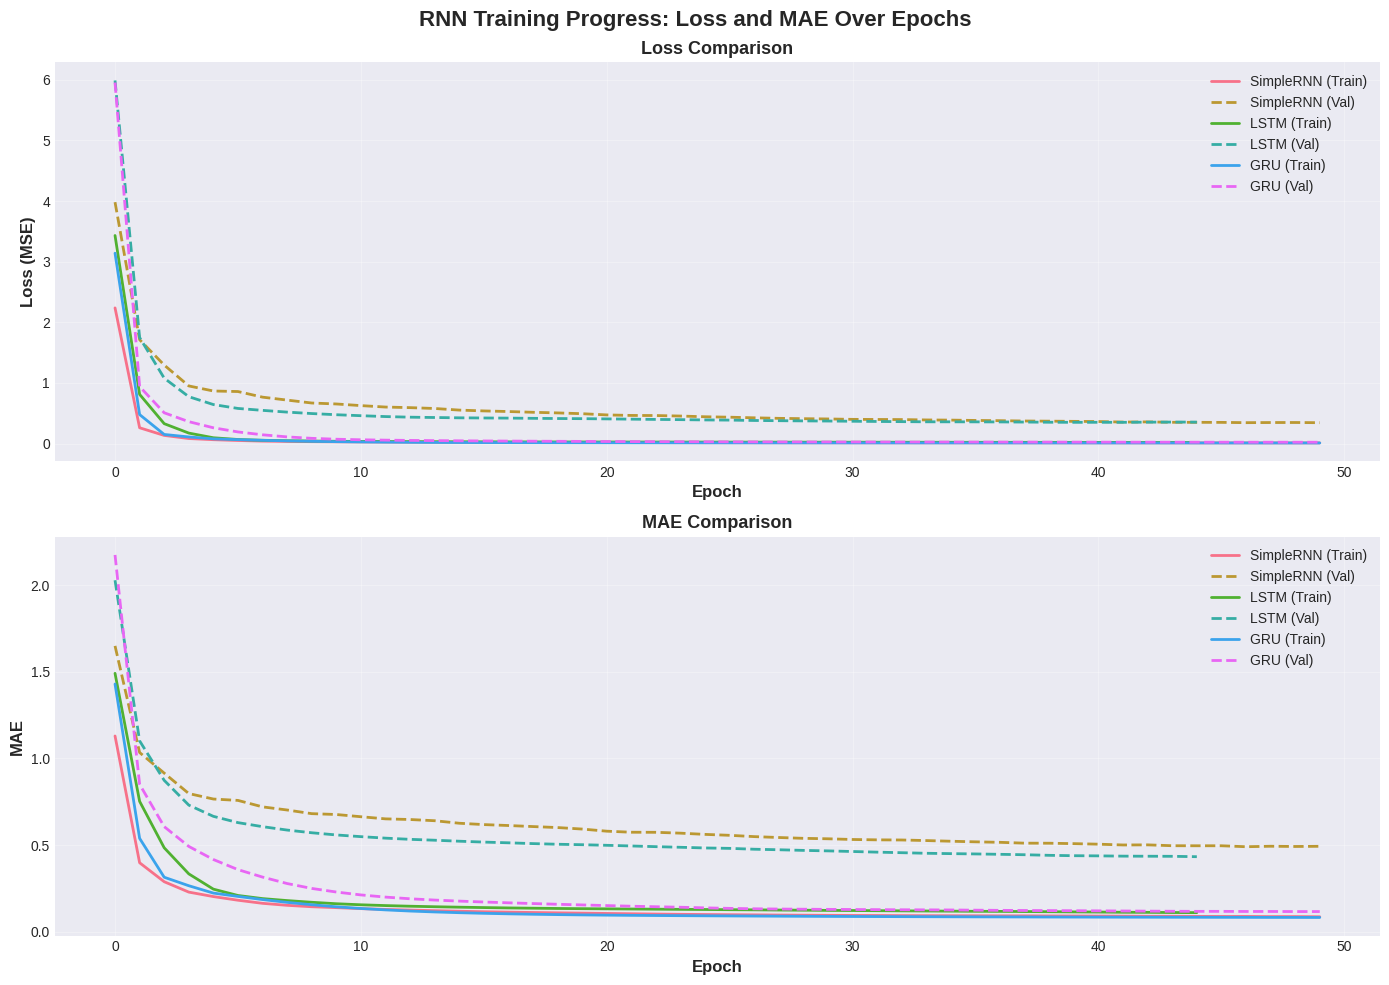

✅ Training progress visualization created!


In [17]:
# Plot training history for all RNN models
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('RNN Training Progress: Loss and MAE Over Epochs', fontsize=16, fontweight='bold')

# Loss comparison
axes[0].plot(history_simple_rnn.history['loss'], label='SimpleRNN (Train)', linestyle='-', linewidth=2)
axes[0].plot(history_simple_rnn.history['val_loss'], label='SimpleRNN (Val)', linestyle='--', linewidth=2)
axes[0].plot(history_lstm.history['loss'], label='LSTM (Train)', linestyle='-', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='LSTM (Val)', linestyle='--', linewidth=2)
axes[0].plot(history_gru.history['loss'], label='GRU (Train)', linestyle='-', linewidth=2)
axes[0].plot(history_gru.history['val_loss'], label='GRU (Val)', linestyle='--', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('Loss Comparison', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE comparison
axes[1].plot(history_simple_rnn.history['mae'], label='SimpleRNN (Train)', linestyle='-', linewidth=2)
axes[1].plot(history_simple_rnn.history['val_mae'], label='SimpleRNN (Val)', linestyle='--', linewidth=2)
axes[1].plot(history_lstm.history['mae'], label='LSTM (Train)', linestyle='-', linewidth=2)
axes[1].plot(history_lstm.history['val_mae'], label='LSTM (Val)', linestyle='--', linewidth=2)
axes[1].plot(history_gru.history['mae'], label='GRU (Train)', linestyle='-', linewidth=2)
axes[1].plot(history_gru.history['val_mae'], label='GRU (Val)', linestyle='--', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE', fontsize=12, fontweight='bold')
axes[1].set_title('MAE Comparison', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Training progress visualization created!")

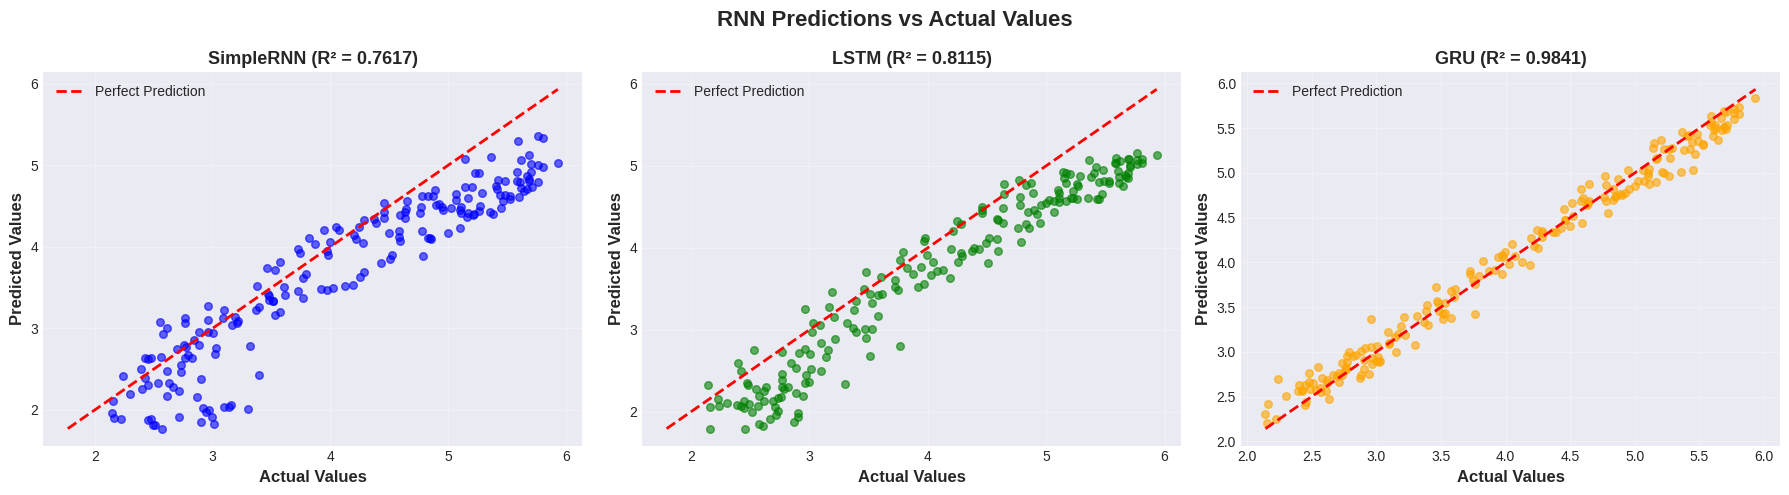

✅ Predictions visualization created!


In [18]:
# Plot predictions vs actual values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RNN Predictions vs Actual Values', fontsize=16, fontweight='bold')

# SimpleRNN
axes[0].scatter(y_test_seq, y_pred_simple_rnn, alpha=0.6, s=30, color='blue')
min_val = min(y_test_seq.min(), y_pred_simple_rnn.min())
max_val = max(y_test_seq.max(), y_pred_simple_rnn.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
axes[0].set_title(f'SimpleRNN (R² = {r2_simple_rnn:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LSTM
axes[1].scatter(y_test_seq, y_pred_lstm, alpha=0.6, s=30, color='green')
min_val = min(y_test_seq.min(), y_pred_lstm.min())
max_val = max(y_test_seq.max(), y_pred_lstm.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Values', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
axes[1].set_title(f'LSTM (R² = {r2_lstm:.4f})', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# GRU
axes[2].scatter(y_test_seq, y_pred_gru, alpha=0.6, s=30, color='orange')
min_val = min(y_test_seq.min(), y_pred_gru.min())
max_val = max(y_test_seq.max(), y_pred_gru.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Values', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
axes[2].set_title(f'GRU (R² = {r2_gru:.4f})', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Predictions visualization created!")

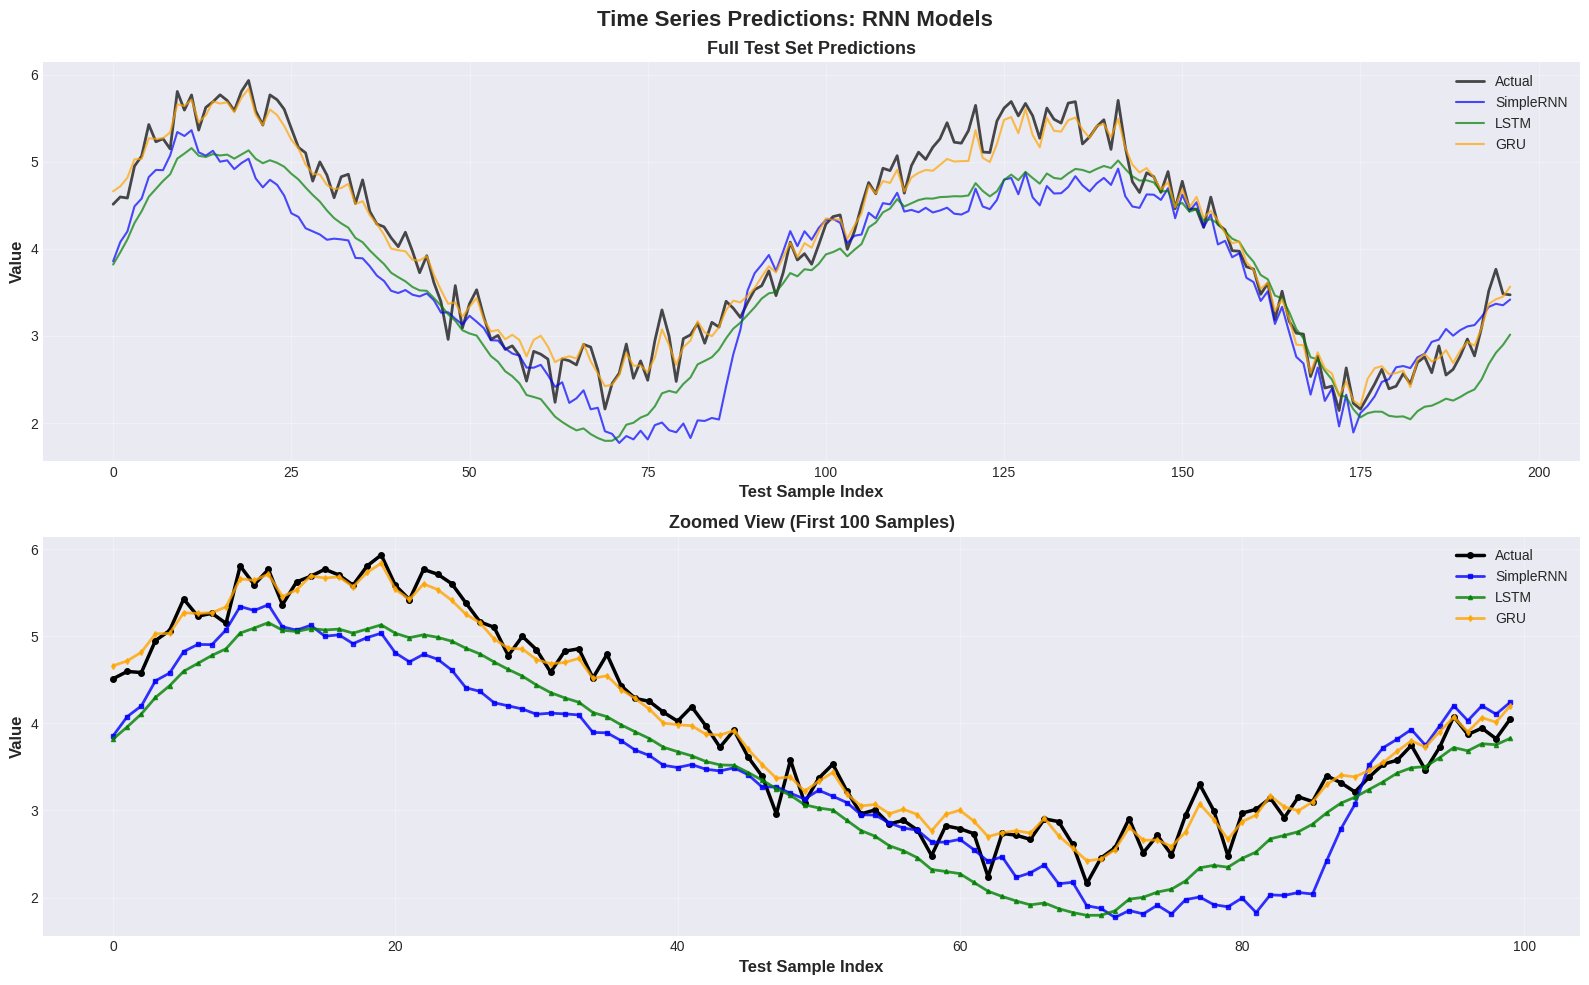

✅ Time series predictions visualization created!


In [19]:
# Plot time series predictions
test_indices = np.arange(len(y_test_seq))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Time Series Predictions: RNN Models', fontsize=16, fontweight='bold')

# Full test set
axes[0].plot(test_indices, y_test_seq, label='Actual', linewidth=2, color='black', alpha=0.7)
axes[0].plot(test_indices, y_pred_simple_rnn, label='SimpleRNN', linewidth=1.5, alpha=0.7, color='blue')
axes[0].plot(test_indices, y_pred_lstm, label='LSTM', linewidth=1.5, alpha=0.7, color='green')
axes[0].plot(test_indices, y_pred_gru, label='GRU', linewidth=1.5, alpha=0.7, color='orange')
axes[0].set_xlabel('Test Sample Index', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
axes[0].set_title('Full Test Set Predictions', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoomed view (first 100 samples)
zoom_range = 100
axes[1].plot(test_indices[:zoom_range], y_test_seq[:zoom_range], label='Actual', 
            linewidth=2.5, color='black', marker='o', markersize=4)
axes[1].plot(test_indices[:zoom_range], y_pred_simple_rnn[:zoom_range], label='SimpleRNN', 
            linewidth=2, alpha=0.8, color='blue', marker='s', markersize=3)
axes[1].plot(test_indices[:zoom_range], y_pred_lstm[:zoom_range], label='LSTM', 
            linewidth=2, alpha=0.8, color='green', marker='^', markersize=3)
axes[1].plot(test_indices[:zoom_range], y_pred_gru[:zoom_range], label='GRU', 
            linewidth=2, alpha=0.8, color='orange', marker='d', markersize=3)
axes[1].set_xlabel('Test Sample Index', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Value', fontsize=12, fontweight='bold')
axes[1].set_title(f'Zoomed View (First {zoom_range} Samples)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Time series predictions visualization created!")

## Step 14: Model Comparison Visualization. 

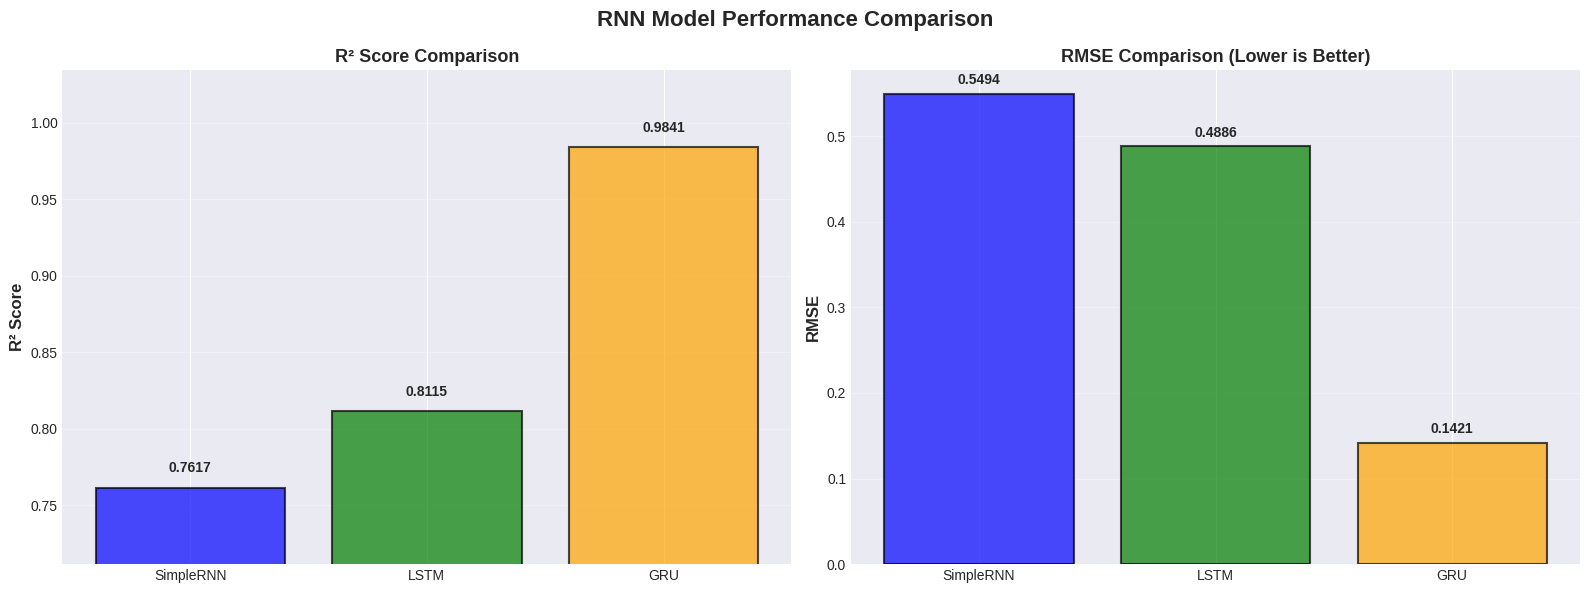

✅ Model comparison visualization created!


In [20]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RNN Model Performance Comparison', fontsize=16, fontweight='bold')

# R² comparison
models = ['SimpleRNN', 'LSTM', 'GRU']
r2_scores = [r2_simple_rnn, r2_lstm, r2_gru]
colors = ['blue', 'green', 'orange']

axes[0].bar(models, r2_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim([min(r2_scores) - 0.05, max(r2_scores) + 0.05])
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE comparison
rmse_scores = [rmse_simple_rnn, rmse_lstm, rmse_gru]

axes[1].bar(models, rmse_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('RMSE', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + max(rmse_scores)*0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Model comparison visualization created!")

## Step 15: Visualize LSTM Cell Structure

Let's understand how LSTM cells work with their gates.

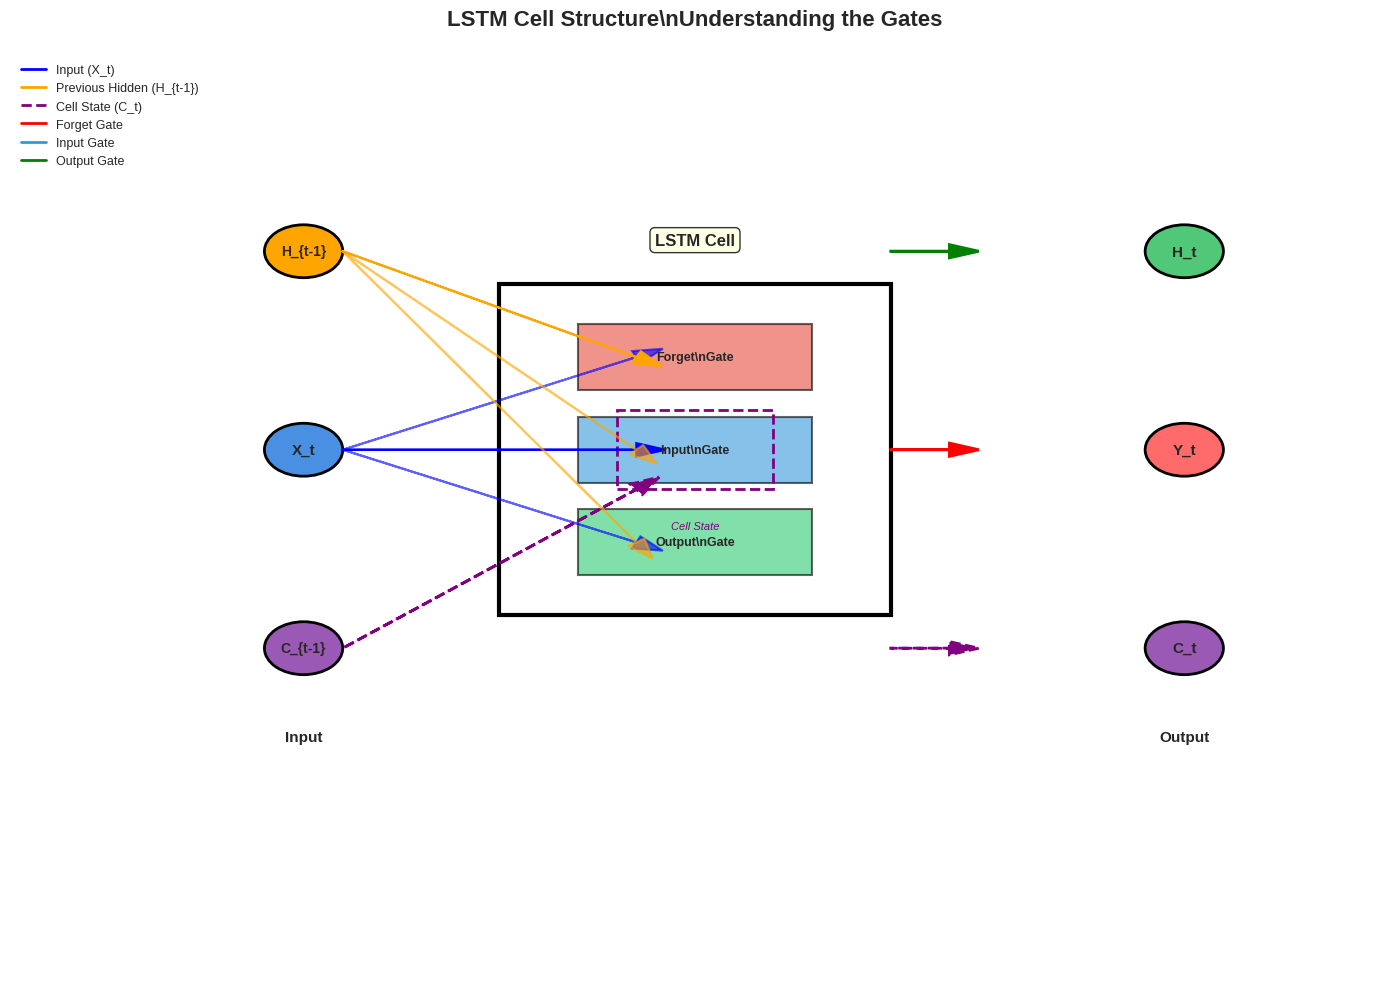

✅ LSTM cell structure visualization created!
\n💡 LSTM Gates:
   - Forget Gate: Decides what to forget from cell state
   - Input Gate: Decides what new information to store
   - Output Gate: Decides what to output based on cell state
   - Cell State: Long-term memory that flows through time


In [21]:
# Visualize LSTM cell structure
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.axis('off')
ax.set_title('LSTM Cell Structure\\nUnderstanding the Gates', fontsize=16, fontweight='bold', pad=20)

# Draw LSTM cell
cell_x, cell_y = 2.5, 3
cell_width, cell_height = 2, 2.5

# Main cell box
rect = Rectangle((cell_x - cell_width/2, cell_y - cell_height/2), cell_width, cell_height,
                fill=False, edgecolor='black', linewidth=3)
ax.add_patch(rect)

# Input
circle_x = Circle((0.5, cell_y), 0.2, color='#4A90E2', ec='black', lw=2)
ax.add_patch(circle_x)
ax.text(0.5, cell_y, 'X_t', ha='center', va='center', fontsize=11, fontweight='bold')

# Previous hidden state
circle_h_prev = Circle((0.5, cell_y + 1.5), 0.2, color='#FFA500', ec='black', lw=2)
ax.add_patch(circle_h_prev)
ax.text(0.5, cell_y + 1.5, 'H_{t-1}', ha='center', va='center', fontsize=10, fontweight='bold')

# Previous cell state
circle_c_prev = Circle((0.5, cell_y - 1.5), 0.2, color='#9B59B6', ec='black', lw=2)
ax.add_patch(circle_c_prev)
ax.text(0.5, cell_y - 1.5, 'C_{t-1}', ha='center', va='center', fontsize=10, fontweight='bold')

# Gates (inside cell)
gate_y_positions = [cell_y + 0.7, cell_y, cell_y - 0.7]
gate_names = ['Forget\\nGate', 'Input\\nGate', 'Output\\nGate']
gate_colors = ['#E74C3C', '#3498DB', '#2ECC71']

for i, (y_pos, name, color) in enumerate(zip(gate_y_positions, gate_names, gate_colors)):
    rect_gate = Rectangle((cell_x - 0.6, y_pos - 0.25), 1.2, 0.5,
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.6)
    ax.add_patch(rect_gate)
    ax.text(cell_x, y_pos, name, ha='center', va='center', fontsize=9, fontweight='bold')

# Cell state (inside)
rect_c = Rectangle((cell_x - 0.4, cell_y - 0.3), 0.8, 0.6,
                  fill=False, edgecolor='purple', linewidth=2, linestyle='--')
ax.add_patch(rect_c)
ax.text(cell_x, cell_y - 0.6, 'Cell State', ha='center', fontsize=8, style='italic', color='purple')

# Output hidden state
circle_h = Circle((5, cell_y + 1.5), 0.2, color='#50C878', ec='black', lw=2)
ax.add_patch(circle_h)
ax.text(5, cell_y + 1.5, 'H_t', ha='center', va='center', fontsize=11, fontweight='bold')

# Output cell state
circle_c = Circle((5, cell_y - 1.5), 0.2, color='#9B59B6', ec='black', lw=2)
ax.add_patch(circle_c)
ax.text(5, cell_y - 1.5, 'C_t', ha='center', va='center', fontsize=11, fontweight='bold')

# Output
circle_y = Circle((5, cell_y), 0.2, color='#FF6B6B', ec='black', lw=2)
ax.add_patch(circle_y)
ax.text(5, cell_y, 'Y_t', ha='center', va='center', fontsize=11, fontweight='bold')

# Connections
# Input to gates
ax.arrow(0.7, cell_y, 1.5, 0, head_width=0.1, head_length=0.15, fc='blue', ec='blue', linewidth=1.5)
ax.arrow(0.7, cell_y, 1.5, 0.7, head_width=0.1, head_length=0.15, fc='blue', ec='blue', linewidth=1.5, alpha=0.6)
ax.arrow(0.7, cell_y, 1.5, -0.7, head_width=0.1, head_length=0.15, fc='blue', ec='blue', linewidth=1.5, alpha=0.6)

# Previous hidden to gates
ax.arrow(0.7, cell_y + 1.5, 1.5, -0.8, head_width=0.1, head_length=0.15, fc='orange', ec='orange', linewidth=1.5)
ax.arrow(0.7, cell_y + 1.5, 1.5, -1.5, head_width=0.1, head_length=0.15, fc='orange', ec='orange', linewidth=1.5, alpha=0.6)
ax.arrow(0.7, cell_y + 1.5, 1.5, -2.2, head_width=0.1, head_length=0.15, fc='orange', ec='orange', linewidth=1.5, alpha=0.6)

# Previous cell state
ax.arrow(0.7, cell_y - 1.5, 1.5, 1.2, head_width=0.1, head_length=0.15, fc='purple', ec='purple', linewidth=2, linestyle='--')

# Output connections
ax.arrow(cell_x + cell_width/2, cell_y + 1.5, 0.3, 0, head_width=0.1, head_length=0.15, fc='green', ec='green', linewidth=2)
ax.arrow(cell_x + cell_width/2, cell_y - 1.5, 0.3, 0, head_width=0.1, head_length=0.15, fc='purple', ec='purple', linewidth=2, linestyle='--')
ax.arrow(cell_x + cell_width/2, cell_y, 0.3, 0, head_width=0.1, head_length=0.15, fc='red', ec='red', linewidth=2)

# Labels
ax.text(0.5, cell_y - 2.2, 'Input', ha='center', fontsize=11, fontweight='bold')
ax.text(5, cell_y - 2.2, 'Output', ha='center', fontsize=11, fontweight='bold')
ax.text(cell_x, cell_y + cell_height/2 + 0.3, 'LSTM Cell', ha='center', fontsize=12, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='black', alpha=0.8))

# Legend
legend_elements = [
    plt.Line2D([0], [0], color='blue', lw=2, label='Input (X_t)'),
    plt.Line2D([0], [0], color='orange', lw=2, label='Previous Hidden (H_{t-1})'),
    plt.Line2D([0], [0], color='purple', lw=2, linestyle='--', label='Cell State (C_t)'),
    plt.Line2D([0], [0], color='red', lw=2, label='Forget Gate'),
    plt.Line2D([0], [0], color='#3498DB', lw=2, label='Input Gate'),
    plt.Line2D([0], [0], color='green', lw=2, label='Output Gate')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ LSTM cell structure visualization created!")
print("\\n💡 LSTM Gates:")
print("   - Forget Gate: Decides what to forget from cell state")
print("   - Input Gate: Decides what new information to store")
print("   - Output Gate: Decides what to output based on cell state")
print("   - Cell State: Long-term memory that flows through time")

## Step 16: Compare RNN Types

Let's create a comparison table of different RNN architectures.

📊 Comprehensive RNN Model Comparison:
    Model  Parameters       R²     RMSE      MAE Complexity     Memory Training Speed
SimpleRNN        6465 0.761663 0.549447 0.445852        Low Short-term           Fast
     LSTM       19521 0.811547 0.488575 0.421732       High  Long-term           Slow
      GRU       15361 0.984061 0.142091 0.113568     Medium  Long-term         Medium


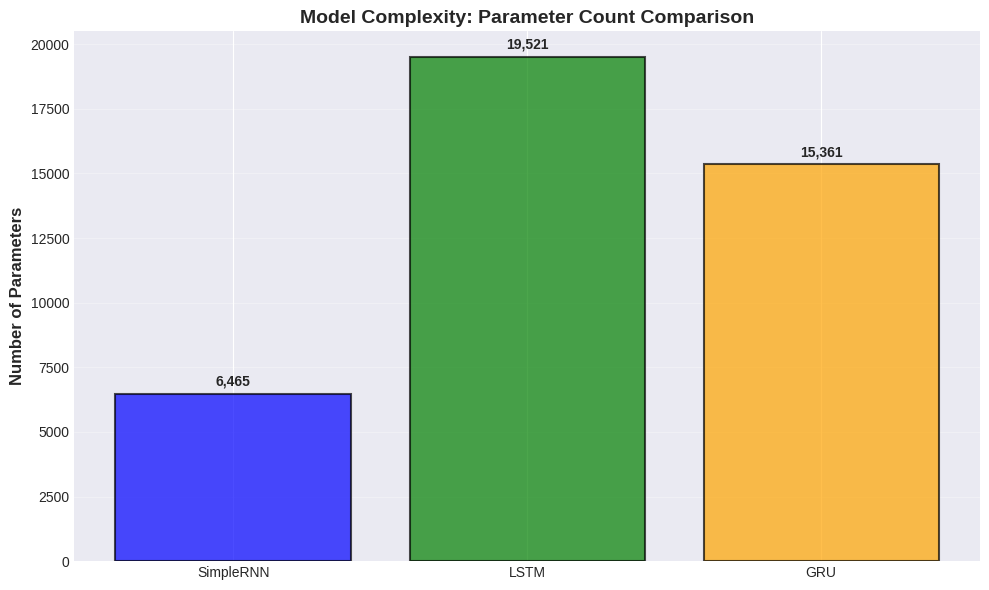

\n💡 Key Differences:
   - SimpleRNN: Simplest, fastest, but limited memory
   - LSTM: Most complex, best for long sequences, most parameters
   - GRU: Balance between complexity and performance


In [22]:
# Count parameters for each model
def count_parameters(model):
    return model.count_params()

param_counts = {
    'SimpleRNN': count_parameters(model_simple_rnn),
    'LSTM': count_parameters(model_lstm),
    'GRU': count_parameters(model_gru)
}

# Create comprehensive comparison
comparison_extended = {
    'Model': ['SimpleRNN', 'LSTM', 'GRU'],
    'Parameters': [param_counts['SimpleRNN'], param_counts['LSTM'], param_counts['GRU']],
    'R²': [r2_simple_rnn, r2_lstm, r2_gru],
    'RMSE': [rmse_simple_rnn, rmse_lstm, rmse_gru],
    'MAE': [mae_simple_rnn, mae_lstm, mae_gru],
    'Complexity': ['Low', 'High', 'Medium'],
    'Memory': ['Short-term', 'Long-term', 'Long-term'],
    'Training Speed': ['Fast', 'Slow', 'Medium']
}

comparison_ext_df = pd.DataFrame(comparison_extended)

print("📊 Comprehensive RNN Model Comparison:")
print("=" * 100)
print(comparison_ext_df.to_string(index=False))

# Visualize parameter counts
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bars = ax.bar(comparison_ext_df['Model'], comparison_ext_df['Parameters'], 
             color=['blue', 'green', 'orange'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Parameters', fontsize=12, fontweight='bold')
ax.set_title('Model Complexity: Parameter Count Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, count) in enumerate(zip(bars, comparison_ext_df['Parameters'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(comparison_ext_df['Parameters'])*0.01,
            f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\\n💡 Key Differences:")
print("   - SimpleRNN: Simplest, fastest, but limited memory")
print("   - LSTM: Most complex, best for long sequences, most parameters")
print("   - GRU: Balance between complexity and performance")

## 🎓 Summary and Key Takeaways

### ✅ What You've Learned:

1. **RNN Fundamentals**:
   - RNNs process sequences one timestep at a time
   - Maintain hidden state (memory) across timesteps
   - Recurrent connections allow information to flow through time

2. **RNN Types**:
   - **SimpleRNN**: Basic RNN, simple but limited
   - **LSTM**: Long Short-Term Memory, best for long sequences
   - **GRU**: Gated Recurrent Unit, simpler than LSTM, often similar performance

3. **Key Concepts**:
   - **Sequences**: RNNs need sequences, not single data points
   - **Hidden State**: Memory that flows through time
   - **Time Steps**: Each element in the sequence
   - **Gates** (LSTM/GRU): Control information flow

4. **When to Use RNNs**:
   - Time series data (stock prices, sensor readings)
   - Sequential data (text, speech)
   - When order matters
   - When past information is important for predictions

### 💡 Important Insights:

- **RNNs vs Feedforward Networks**: RNNs have memory, feedforward networks don't
- **Sequence Length**: Longer sequences = more context, but harder to train
- **LSTM vs GRU**: LSTM more complex, GRU often similar performance
- **Vanishing Gradient**: SimpleRNN can struggle with long sequences (LSTM/GRU solve this)

### 📚 RNN Architecture Comparison:

| Type | Complexity | Memory | Best For | Parameters |
|------|-----------|--------|----------|------------|
| **SimpleRNN** | Low | Short-term | Short sequences | Fewest |
| **LSTM** | High | Long-term | Long sequences | Most |
| **GRU** | Medium | Long-term | Medium-long sequences | Medium |

### 🔧 Best Practices for RNNs:

1. **Sequence Length**: Choose based on your data (typically 10-50 timesteps)
2. **Scaling**: Always scale your data (StandardScaler or MinMaxScaler)
3. **Architecture**: Start with SimpleRNN, try LSTM/GRU if needed
4. **Return Sequences**: Use `return_sequences=True` for stacked layers
5. **Dropout**: Add dropout to prevent overfitting
6. **Early Stopping**: Monitor validation loss

### 🆚 RNN vs Feedforward NN:

| Aspect | Feedforward NN | RNN |
|--------|---------------|-----|
| **Input** | Single data point | Sequence of data points |
| **Memory** | None | Hidden state |
| **Use Case** | Static data | Time series, sequences |
| **Order** | Doesn't matter | Matters |
| **Context** | No temporal context | Uses past context |

---

**Great job learning Recurrent Neural Networks! 🔄🧠✨**

## Step 10: Compare All RNN Modelsiza